In [1]:
from pathlib import Path
import opencosmo as oc
import numpy as np
import matplotlib.pyplot as plt
import opencosmo
import halotools
import time 

from halotools.empirical_models import HodModelFactory
from halotools.empirical_models import TrivialPhaseSpace, SubhaloPhaseSpace, Zheng07Cens, Zheng07Sats
from halotools.empirical_models.ia_models.ia_model_components import CentralAlignment, RadialSatelliteAlignment, SubhaloAlignment, SatelliteAlignment
from diffsky.ellipsoidal_shapes.ellipse_proj_kernels import mc_mu_phi
import time
import h5py
import os
import sys
import treecorr
from astropy.cosmology import FlatLambdaCDM

# Import correlation functions
from halotools.mock_observables.ia_correlations import ed_3d, ee_3d, ed_projected, ee_projected
from halotools.mock_observables import tpcf

# Modular alignment code
sys.path.append("/home/u17/jiachuanxu/diffsky/modular_alignments")
from modular_alignment import align_to_halo, align_radially, get_galaxy_positions, project_alignments_with_NCP, get_position_angle
from ellipse_proj_kernels_v2 import _project_ellipsoid_scalar, compute_ellipse2d, mc_mu_phi_gamma
from jax import random

from random_catalog import make_random_catalog

In [57]:
def euler_angles_ZXZ(A, B, C, ellipsoid_domain=False):
    """
    Recover ZXZ intrinsic Euler angles (alpha, beta, gamma) from rotated axes.
    The input axes A, B, C are aligned with the rotated x, y, z axes, respectively.

    Convention (intrinsic, body-frame rotations):
      1. Rotate around z      by alpha  -> x moves to intermediate x'
      2. Rotate around new x' by beta   -> z moves to final z'' = C
      3. Rotate around new z'' by gamma -> final x''' = A, final y''' = B

    The full rotation matrix R = Rz(alpha) @ Rx(beta) @ Rz(gamma) (?) has columns
    [A, B, C], mapping the original (x,y,z) axes onto (A,B,C).

    Derivation (from the analytic expansion of R = Rz(a)·Rx(b)·Rz(g)):
      C_z =  cos(beta)                        -> beta  = arccos(C_z)
      C_x =  sin(alpha)*sin(beta)  }          -> alpha = atan2(C_x, -C_y)
      C_y = -cos(alpha)*sin(beta)  }
      A_z =  sin(beta)*sin(gamma)  }          -> gamma = atan2(A_z, B_z)
      B_z =  sin(beta)*cos(gamma)  }

    Gimbal lock (sin(beta) ~ 0): only alpha +/- gamma is determined;
    by convention gamma is set to 0.

    Parameters
    ----------
    A, B, C : array_like, shape (..., 3)
        Vectors of the new x, y, z axes. The function will normalize them to unit 
        vectors and assert that they form a right-handed frame.

    ellipsoid_domain : bool, optional
        If True, map angles to the irreducible domain of a triaxial ellipsoid using
        the R_C(pi) and R_A(pi) body-frame symmetries:
            alpha in [0, 2*pi),  beta in [0, pi/2],  gamma in [0, pi)
        If False (default), return the standard ZXZ ranges:
            alpha in [0, 2*pi),  beta in [0, pi],    gamma in [0, 2*pi)

    Returns
    -------
    alpha, beta, gamma : ndarray
        Euler angles in radians.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    C = np.asarray(C, dtype=float)

    # Normalize inputs to unit vectors
    A = A / np.linalg.norm(A, axis=-1, keepdims=True)
    B = B / np.linalg.norm(B, axis=-1, keepdims=True)
    C = C / np.linalg.norm(C, axis=-1, keepdims=True)

    # Assert right-hand relation: (A x B) must be close to C
    AxB = np.cross(A, B)
    assert np.allclose(AxB, C, atol=5e-5), (
        f"A, B, C are not a right-handed frame: max |AxB - C| = {np.max(np.abs(AxB - C)):.2e}")

    cos_beta = np.clip(C[..., 2], -1.0, 1.0)
    beta     = np.arccos(cos_beta)
    sin_beta = np.sin(beta)

    no_lock = np.abs(sin_beta) > 1e-10

    # General case: invert the analytic expressions above.
    # Gimbal lock fallback: alpha absorbs the free angle, gamma = 0.
    alpha = np.where(no_lock,
                     np.arctan2( C[..., 0], -C[..., 1]),   # atan2(C_x, -C_y)
                     np.arctan2( A[..., 1],  A[..., 0]))   # atan2(A_y,  A_x)
    gamma = np.where(no_lock,
                     np.arctan2(A[..., 2], B[..., 2]),     # atan2(A_z, B_z)
                     0.0)

    # Wrap to required ranges: alpha, gamma in [0, 2pi]; beta already in [0, pi]
    alpha = alpha % (2.0 * np.pi)
    gamma = gamma % (2.0 * np.pi)

    if ellipsoid_domain:
        # R_C(pi) symmetry: fold gamma into [0, pi)
        gamma = gamma % np.pi
        # R_A(pi) symmetry: fold beta into [0, pi/2], adjusting alpha and gamma consistently
        needs_flip = beta > np.pi / 2
        alpha = (alpha + np.where(needs_flip, np.pi, 0.0)) % (2 * np.pi)
        gamma = np.where(needs_flip, (np.pi - gamma) % np.pi, gamma)
        beta  = np.where(needs_flip, np.pi - beta, beta)

    return alpha, beta, gamma

def observer_frame_axes(ra_rad, dec_rad, ascending_ra_rad=3.14159265358979323):
    """
    Observer frame unit vectors (West, North, -LOS) in the simulation frame,
    assuming the standard mapping: r̂ = (cos δ cos (α-ascending_ra_rad), -cos δ sin (α-ascending_ra_rad), sin δ), where 
    δ is declination and α is right ascension. 

    Parameters
    ----------
    ra_rad, dec_rad : array_like, shape (N,)  [radians]
        ra_rad in [0, 2Pi), dec_rad in [-Pi/2, Pi/2]
    ascending_ra_rad : float, optional
        Right ascension of the ascending node (default = pi, i.e. x-axis points toward RA=pi, Dec=0).
    Returns
    -------
    x_prime : ndarray (N, 3)  West = direction of decreasing RA
    y_prime : ndarray (N, 3)  North = direction of increasing Dec
    z_prime : ndarray (N, 3)  -LOS = toward observer, z' = x' × y'
    """
    alpha  = np.asarray(ra_rad - ascending_ra_rad,  dtype=float)
    delta  = np.asarray(dec_rad, dtype=float)
    ca, sa = np.cos(alpha),  np.sin(alpha)
    cd, sd = np.cos(delta), np.sin(delta)
    zeros  = np.zeros_like(alpha)

    x_prime = np.stack([ sa,       -ca,        zeros], axis=-1)   # West
    y_prime = np.stack([-sd*ca,    -sd*sa,     cd   ], axis=-1)   # North
    z_prime = np.stack([-cd*ca,    -cd*sa,    -sd   ], axis=-1)   # -LOS

    return x_prime, y_prime, z_prime

def transform_axes_to_frame(A, B, C, x_prime, y_prime, z_prime):
    """
    Re-express ellipsoid axes A, B, C in the frame (x', y', z').
    All inputs shape (N, 3). Returns (A_obs, B_obs, C_obs), shape (N, 3).
    """
    def _dot(V, frame_ax):
        return np.sum(V * frame_ax, axis=-1)

    def _to_frame(V):
        return np.stack([_dot(V, x_prime), _dot(V, y_prime), _dot(V, z_prime)], axis=-1)

    return _to_frame(A), _to_frame(B), _to_frame(C)


# ── validation ────────────────────────────────────────────────────────────────

def _ZXZ_matrix(a, b, g):
    """Build the ZXZ rotation matrix from Euler angles (scalar or array inputs)."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    g = np.asarray(g, dtype=float)
    ca, sa = np.cos(a), np.sin(a)
    cb, sb = np.cos(b), np.sin(b)
    cg, sg = np.cos(g), np.sin(g)
    return np.array([
        [ ca*cg - sa*cb*sg,  -ca*sg - sa*cb*cg,  sa*sb],
        [ sa*cg + ca*cb*sg,  -sa*sg + ca*cb*cg, -ca*sb],
        [ sb*sg,              sb*cg,              cb   ],
    ])

_tests = [
    (0.3,       1.2,    0.7),   # general
    (1.1,       0.5,   -0.8),   # general
    (1.1,       0.0,    0.5),   # gimbal lock beta=0
    (0.6,  np.pi,       0.2),   # gimbal lock beta=pi
    (0.0,       0.0,    0.0),   # identity
]
for _a, _b, _g in _tests:
    _R  = _ZXZ_matrix(_a, _b, _g)
    _ar, _br, _gr = euler_angles_ZXZ(_R[:, 0], _R[:, 1], _R[:, 2])
    _Rr = _ZXZ_matrix(_ar, _br, _gr)
    assert np.allclose(_R, _Rr, atol=1e-12), f"Round-trip failed for ({_a:.2f}, {_b:.2f}, {_g:.2f})"
print("All ZXZ Euler angle round-trip tests passed.")

All ZXZ Euler angle round-trip tests passed.


In [3]:
euler_angles_ZXZ(np.array([1, 0, 0]), 
                 np.array([0, 1, -1]), 
                 np.array([0, 1, 1]), 
                 ellipsoid_domain=True)

(np.float64(3.141592653589793), array(0.78539816), array(0.))

In [4]:
# Eliminate halos with 0 or fill value for the 3D halo major axis
def mask_bad_halocat(halocat, fill_value=None, 
    halo_axis_keys=["top_host_infall_fof_halo_eigS3X", "top_host_infall_fof_halo_eigS3Y", "top_host_infall_fof_halo_eigS3Z"], atol=1e-8):
    
    bad_mask = np.isclose(halocat[halo_axis_keys[0]].value, 0, atol=atol) | \
               np.isclose(halocat[halo_axis_keys[1]].value, 0, atol=atol) | \
               np.isclose(halocat[halo_axis_keys[2]].value, 0, atol=atol) | \
               (np.abs(halocat[halo_axis_keys[0]].value) > 100.0) | \
               (np.abs(halocat[halo_axis_keys[1]].value) > 100.0) | \
               (np.abs(halocat[halo_axis_keys[2]].value) > 100.0)
    if fill_value:
        bad_mask_fill = np.isclose(halocat[halo_axis_keys[0]].value, fill_value, atol=atol) | \
                   np.isclose(halocat[halo_axis_keys[1]].value, fill_value, atol=atol) | \
                   np.isclose(halocat[halo_axis_keys[2]].value, fill_value, atol=atol)
        bad_mask = bad_mask | bad_mask_fill
    return bad_mask

def select_wl_sample(dataset,
                     J_depth_5sigma=26.5,
                     H_depth_5sigma=26.5,
                     snr_min=18.0,
                     R_min=0.4,
                     comoving=True):
    """
    Select weak lensing sample with two criteria:
      1. J+H combined SNR > snr_min
      2. Spatial resolution factor R > R_min

    SNR per band: SNR = 5 * 10^((m5 - m) / 2.5), where m5 is the 5-sigma depth.
    Combined SNR: SNR_JH = sqrt(SNR_J^2 + SNR_H^2).

    Resolution factor R = (1 + EE50PSF_eff^2 / r50_disk^2)^-1, where EE50PSF_eff
    is the SNR^2-weighted effective PSF half-light radius across J and H bands,
    and r50_disk is the galaxy disk half-light radius (assumed arcsec).

    PSF EE50 radii from NASA GSFC Roman WFI official PSF simulations (SCA01, field center):
      F129 (J band): 0.089 arcsec
      F158 (H band): 0.103 arcsec
    Reference: https://roman.gsfc.nasa.gov/science/WFI_technical.html
    """
    # Roman WFI PSF 50% encircled energy radii [arcsec]
    EE50PSF_J = 0.089  # F129
    EE50PSF_H = 0.103  # F158

    # Per-band SNR from AB magnitudes
    snr_J = 5.0 * 10.0**((J_depth_5sigma - dataset.data["roman_F129"].value) / 2.5)
    snr_H = 5.0 * 10.0**((H_depth_5sigma - dataset.data["roman_F158"].value) / 2.5)
    snr_JH = np.sqrt(snr_J**2 + snr_H**2)

    # SNR^2-weighted effective PSF EE50^2 for the combined J+H measurement
    snr_J2 = snr_J**2
    snr_H2 = snr_H**2
    EE50PSF_eff2 = (snr_J2 * EE50PSF_J**2 + snr_H2 * EE50PSF_H**2) / (snr_J2 + snr_H2)

    # Galaxy half-light radius (r50_disk in arcsec in the lightcone catalog)
    if comoving:
      r_eff = dataset.data["r50_disk"] # in comoving kpc
    else:
       r_eff = dataset.data["r50_disk"] * (1 + dataset.data["redshift"])  # Convert to comoving kpc
    comoving_distance =  dataset.cosmology.comoving_distance(dataset.data["redshift"])
    r_eff_arcsec = (r_eff/comoving_distance).to("1").value * 206265.0  # Convert radians to arcsec

    # Spatial resolution factor
    R = 1.0 / (1.0 + EE50PSF_eff2 / r_eff_arcsec**2)

    wl_mask = (snr_JH > snr_min) & (R > R_min)
    return wl_mask

In [5]:
### Loading Roman Mock Catalog
mock_data_path = "/xdisk/timeifler/jiachuanxu/hlwas_cosmos_260215_02_17_2026"
data_path = Path(mock_data_path)
files = [f for f in data_path.glob("lc_cores*.hdf5")]
print(files)
print(f'Found {len(files)} hdf5 files starting with lc_cores')
# get a copy of full data description
with oc.open(files[1], synth_cores=False) as _d:
    _d = _d.with_units("comoving")
    _d = _d.take(10, at="start")
    full_data_description = _d.descriptions

# load part of the data columns 
### Note that the eigen vector has a unit of Mpc and |eigS3| >= |eigS2| >= |eigS1|
dataset = oc.open(files, synth_cores=False)
dataset = dataset.select("gal_id", "redshift*", "redshift", "*bulge*", "*disk*", "central", "logm*", "roman_F129", "roman_F158", 
                         "lsst_r",  "lsst_i", "top_host_idx", "top_host_infall_fof_halo_eigS*", "x", "y", "z", "ra*", "dec*",
                         "r50_*", "*_host", "x_nfw", "y_nfw", "z_nfw")
# filter with redshift range, take some random objects
#dataset = dataset.with_redshift_range(0.5, 0.8)
dataset = dataset.with_units("comoving")
dataset = dataset.take(2_000_000, at="random")
Lbox = dataset.header.simulation["box_size"].value / dataset.cosmology.h

### Select weak lensing source sample as a subset (not including shape measurement error so far)
# Preview selection fraction
wl_mask = select_wl_sample(dataset, J_depth_5sigma=26.4+1, H_depth_5sigma=26.4+1, R_min=0.4)
dataset = dataset.with_new_columns(wl_sample = wl_mask)
dataset = dataset.filter(oc.col("wl_sample") == True)
print(f"Total galaxies:      {np.sum(wl_mask):>8,} out of {len(wl_mask):>8,} ({100*np.sum(wl_mask)/len(wl_mask):.1f}%)")

[PosixPath('/xdisk/timeifler/jiachuanxu/hlwas_cosmos_260215_02_17_2026/lc_cores-442.diffsky_gals.hdf5'), PosixPath('/xdisk/timeifler/jiachuanxu/hlwas_cosmos_260215_02_17_2026/lc_cores-121.diffsky_gals.hdf5')]
Found 2 hdf5 files starting with lc_cores
Total galaxies:      1,103,960 out of 2,000,000 (55.2%)


In [6]:
full_data_description

{'redshift': 'None',
 'Halpha': 'Emission line flux (continuum-subtracted)',
 'Halpha_unlensed': None,
 'OII': 'Emission line flux (continuum-subtracted)',
 'OIII': 'Emission line flux (continuum-subtracted)',
 'OIII_unlensed': None,
 'OII_unlensed': None,
 'alpha_bulge': '2d projected size of the semi-minor axis of the bulge',
 'alpha_disk': '2d projected size of the semi-minor axis of the disk',
 'av': 'Dust attenuation curve parameter',
 'b_over_a_bulge': '3d axis ratio b/a, where 0 < b/a < 1',
 'b_over_a_disk': '3d axis ratio b/a, where 0 < b/a < 1',
 'beta_bulge': '2d projected size of the semi-major axis of the bulge',
 'beta_disk': '2d projected size of the semi-major axis of the disk',
 'black_hole_accretion_rate': 'Black hole mass accretion rate',
 'black_hole_eddington_ratio': 'dimensionless Eddington ratio',
 'black_hole_mass': 'Black hole mass',
 'bulge_to_total': 'Bulge-to-total mass ratio',
 'c_over_a_bulge': '3d axis ratio c/a, where 0 < c/a < 1',
 'c_over_a_disk': '3d a

In [7]:
### Add column to mark synthetic cores
syncore_mask = mask_bad_halocat(dataset.data, fill_value=-1.4779781)
dataset = dataset.with_new_columns(synthetic = syncore_mask)
dataset = dataset.filter(oc.col("synthetic") == False)
#dataset = dataset.with_new_columns(synthetic = syncore_mask)
print(f"Number of halos with bad major axis: {np.sum(syncore_mask)}")
print(f"Number of halos after masking: {len(dataset) - np.sum(syncore_mask)}")

central_mask = dataset.data["central"] == 1
satellite_mask = dataset.data["central"] == 0
print(f"Central galaxies:    {np.sum(central_mask):>8,} out of {len(central_mask):>8,} ({100*np.sum(central_mask)/len(central_mask):.1f}%)")

### Overwrite the 3D halo eigenaxes with a ristricted angle range
# A: polar angle = [0, pi/2], azimuthal angle = [0, 2pi]
# B: polar angle = [0, pi], azimuthal angle = [0, 2pi]
# C: polar angle = [0, pi/2], azimuthal angle = [0, 2pi] 
# Tune the range of the halo axes such that the major axis A and minor axis C always have positive z-component
# Note that given this convention, the misalignment angle MUST fill the range of [0, pi].
# If the z-component of A is negative, then flip the direction of A and B
# If the z-component of C is negative, then flip the direction of C and B.
halo_A_3D = np.array([dataset.data["top_host_infall_fof_halo_eigS3X"], 
                    dataset.data["top_host_infall_fof_halo_eigS3Y"], 
                    dataset.data["top_host_infall_fof_halo_eigS3Z"]]).T
halo_B_3D = np.array([dataset.data["top_host_infall_fof_halo_eigS2X"], 
                    dataset.data["top_host_infall_fof_halo_eigS2Y"], 
                    dataset.data["top_host_infall_fof_halo_eigS2Z"]]).T
halo_C_3D = np.array([dataset.data["top_host_infall_fof_halo_eigS1X"], 
                    dataset.data["top_host_infall_fof_halo_eigS1Y"], 
                    dataset.data["top_host_infall_fof_halo_eigS1Z"]]).T
_maskA_ = halo_A_3D[..., 2] < 0
_maskC_ = halo_C_3D[..., 2] < 0
halo_A_3D[_maskA_] *= -1
halo_B_3D[_maskA_] *= -1
halo_C_3D[_maskC_] *= -1
halo_B_3D[_maskC_] *= -1
# assert that the halo axes are still orthogonal after flipping
assert np.allclose(np.einsum("ij,ij->i", halo_A_3D, halo_B_3D), 0, atol=2e-6)
assert np.allclose(np.einsum("ij,ij->i", halo_A_3D, halo_C_3D), 0, atol=2e-6)
# assert that the halo axes are right-handed after flipping
assert np.allclose(np.einsum("ij,ij->i", np.cross(halo_A_3D, halo_B_3D), halo_C_3D), 
                   np.linalg.norm(np.cross(halo_A_3D, halo_B_3D), axis=-1) * np.linalg.norm(halo_C_3D, axis=-1), 
                   atol=2e-6)
for i, halo_axis in enumerate([halo_A_3D, halo_B_3D, halo_C_3D]):
    for j in range(3):
        dataset = dataset.drop(f"top_host_infall_fof_halo_eigS{3-i}{'XYZ'[j]}")
        dataset = dataset.with_new_columns(**{f"top_host_infall_fof_halo_eigS{3-i}{'XYZ'[j]}": halo_axis[..., j]})

# overwrite the halo direction with random orientations for halos with bad major axis
# cen_mu, cen_phi = mc_mu_phi(np.sum(central_mask & syncore_mask), random.key(514))
# cen_axisA_x = np.sqrt(1-cen_mu**2)*np.cos(cen_phi)
# cen_axisA_y = np.sqrt(1-cen_mu**2)*np.sin(cen_phi)
# cen_axisA_z = cen_mu
# axis_unit = dataset.data["top_host_infall_fof_halo_eigS3X"].unit

# for col in ["top_host_infall_fof_halo_eigS3X", "top_host_infall_fof_halo_eigS3Y", "top_host_infall_fof_halo_eigS3Z"]:
#         col_value = dataset.data[col].copy()  # make a copy to avoid modifying the original data
#         col_value[central_mask & syncore_mask] = cen_axisA_x * axis_unit
#         dataset = dataset.drop(*[col,])
#         dataset = dataset.with_new_columns(**{col: col_value})

Number of halos with bad major axis: 56939
Number of halos after masking: 990082
Central galaxies:     946,703 out of 1,047,021 (90.4%)


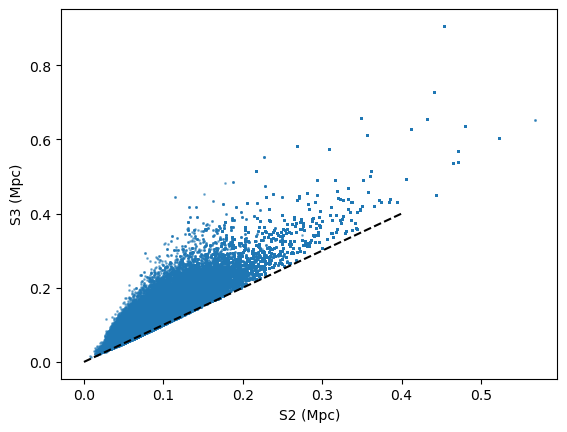

In [8]:
S1 = np.sqrt(dataset.data["top_host_infall_fof_halo_eigS1X"]**2 + dataset.data["top_host_infall_fof_halo_eigS1Y"]**2 + \
     dataset.data["top_host_infall_fof_halo_eigS1Z"]**2)
S2 = np.sqrt(dataset.data["top_host_infall_fof_halo_eigS2X"]**2 + dataset.data["top_host_infall_fof_halo_eigS2Y"]**2 + \
     dataset.data["top_host_infall_fof_halo_eigS2Z"]**2)
S3 = np.sqrt(dataset.data["top_host_infall_fof_halo_eigS3X"]**2 + dataset.data["top_host_infall_fof_halo_eigS3Y"]**2 + \
     dataset.data["top_host_infall_fof_halo_eigS3Z"]**2)
plt.scatter(S1, S2, s=1, alpha=0.5)
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.xlabel("S2 (Mpc)")
plt.ylabel("S3 (Mpc)")
plt.plot([0, 0.4], [0, 0.4], 'k--')

RA estimate error = 1.8726566399702043e-14 deg, Dec estimate error is 8.002040423773236e-14 deg


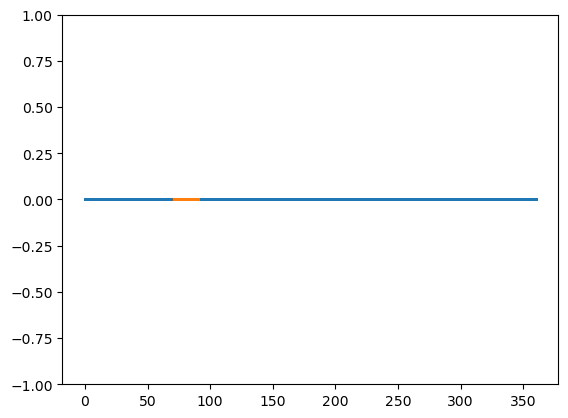

In [9]:
### Understand the transformation between x/y/z and RA/Dec
# Note that the Ra and Dec are defined from x/y/z_nfw
# RA = arctan2(y, x) in degrees + 180, range [0, 360) (-x is RA=0)
# Dec = 90 - arccos(z / sqrt(x^2 + y^2 + z^2)) in degrees, range [-90, 90]
ra_estimate = (np.angle(dataset.data["x_nfw"] + 1j * dataset.data["y_nfw"]).to('deg').value + 180) % 360
dec_estimate = 90 - np.arccos(dataset.data["z_nfw"] / np.sqrt(dataset.data["x_nfw"]**2 + dataset.data["y_nfw"]**2 + dataset.data["z_nfw"]**2)).to('deg').value
plt.scatter(dataset.data["ra"], ra_estimate - dataset.data["ra"].value, s=1)
plt.scatter(dataset.data["dec"], dec_estimate - dataset.data["dec"].value, s=1)
plt.ylim(-1, 1)
ra_estimate_error = np.std(ra_estimate - dataset.data["ra"].value)
dec_estimate_error = np.std(dec_estimate - dataset.data["dec"].value)
print(f'RA estimate error = {ra_estimate_error} deg, Dec estimate error is {dec_estimate_error} deg')

In [10]:
x_prime, y_prime, z_prime = observer_frame_axes(dataset.data["ra"].to('rad').value, 
                                                dataset.data["dec"].to('rad').value)
pos_mag = np.sqrt(dataset.data["x_nfw"]**2 + dataset.data["y_nfw"]**2 + dataset.data["z_nfw"]**2)
pos_test = np.array([dataset.data["x_nfw"]/pos_mag, 
                     dataset.data["y_nfw"]/pos_mag, 
                     dataset.data["z_nfw"]/pos_mag]).T
print(np.allclose(np.sum(pos_test * x_prime, axis=-1), 0.0, atol=2e-6))
print(np.allclose(np.sum(pos_test * y_prime, axis=-1), 0.0, atol=2e-6))
print(np.allclose(np.sum(pos_test * z_prime, axis=-1), -1.0, atol=2e-6))

True
True
True


In [13]:
### From the WL sample, select central and satellite galaxies separately, and build alignment for them separately
def alignment_worker(dataset, central_alignment, satellite_alignment, central_mask, satellite_mask,
                     Lbox=np.inf, envelope=True, random_alignment=False, ra_dec_frame=False, seed=514):
    if random_alignment:
        print("Using random alignment for all galaxies, overwriting central and satellite alignment parameters.")
        mu_ran, phi_ran, gamma_ran = mc_mu_phi_gamma(len(dataset), random.key(seed))
        Ellipse2D_disk = compute_ellipse2d(
            dataset.data["r50_disk"], 
            dataset.data["r50_disk"] * dataset.data["b_over_a_disk"],
            dataset.data["r50_disk"] * dataset.data["c_over_a_disk"],
            mu_ran, phi_ran, gamma_ran,
            envelop=envelope)
        Ellipse2D_bulge = compute_ellipse2d(
            dataset.data["r50_bulge"], 
            dataset.data["r50_bulge"] * dataset.data["b_over_a_bulge"],
            dataset.data["r50_bulge"] * dataset.data["c_over_a_bulge"],
            mu_ran, phi_ran, gamma_ran,
            envelop=envelope)
        _R  = _ZXZ_matrix(phi_ran + np.pi/2., np.arccos(mu_ran), gamma_ran)
        ### save the aligned galaxy axes
        galaxy_axes = {}
        for i, ax in enumerate(["A", "B", "C"]) :
            for j, dim in enumerate(["x", "y", "z"]):
                col_name = "galaxy_axis{}_{}".format(ax, dim)
                col_value = _R[j,i,:]
                galaxy_axes[col_name] = col_value
    else:
        print("Central alignment strength = {}, Satellite alignment strength = {}".format(central_alignment, satellite_alignment))
        ### Central galaxies: aligned to halo 
        central_axes = align_to_halo(
            dataset.data[central_mask]['top_host_infall_fof_halo_eigS3X'].value, 
            dataset.data[central_mask]['top_host_infall_fof_halo_eigS3Y'].value, 
            dataset.data[central_mask]['top_host_infall_fof_halo_eigS3Z'].value, 
            central_alignment, prim_gal_axis='A', 
            #seed=random.key(seed)
            seed=seed
        )

        ### Satellite galaxy: align radially towards the host halo center. 
        satellite_axes = align_radially(
            dataset.data[satellite_mask]['x_host'].value, 
            dataset.data[satellite_mask]['y_host'].value, 
            dataset.data[satellite_mask]['z_host'].value, 
            dataset.data[satellite_mask]['x_nfw'].value, 
            dataset.data[satellite_mask]['y_nfw'].value, 
            dataset.data[satellite_mask]['z_nfw'].value, 
            [Lbox, ]*3, satellite_alignment, prim_gal_axis='A', 
            #seed=random.key(seed)
            seed=seed
        )

        ### save the aligned galaxy axes (direction of alignment, not including the galaxy shape)
        galaxy_axes = {}
        for i, ax in enumerate(["A", "B", "C"]) :
            for j, dim in enumerate(["x", "y", "z"]):
                col_name = "galaxy_axis{}_{}".format(ax, dim)
                col_value = np.zeros(len(dataset))
                col_value[central_mask] = central_axes[i][:,j]
                col_value[satellite_mask] = satellite_axes[i][:,j]
                galaxy_axes[col_name] = col_value
        
        ### project the 3D galaxy shape to 2D on the sky and get the position angle for each galaxy
        gal_A = np.array([galaxy_axes["galaxy_axisA_x"], 
                        galaxy_axes["galaxy_axisA_y"], 
                        galaxy_axes["galaxy_axisA_z"]]).T
        gal_B = np.array([galaxy_axes["galaxy_axisB_x"], 
                        galaxy_axes["galaxy_axisB_y"], 
                        galaxy_axes["galaxy_axisB_z"]]).T
        gal_C = np.array([galaxy_axes["galaxy_axisC_x"], 
                        galaxy_axes["galaxy_axisC_y"], 
                        galaxy_axes["galaxy_axisC_z"]]).T
        if ra_dec_frame:
            ### Measure the galaxy shapes in RA/Dec frame 
            ra_rad = dataset.data["ra_obs"].to('rad').value
            dec_rad = dataset.data["dec_obs"].to('rad').value
            # x_prime = west, y_prime = north, z_prime = -LOS (toward observer)
            x_prime, y_prime, z_prime = observer_frame_axes(ra_rad, dec_rad)
            gal_A_obs, gal_B_obs, gal_C_obs = transform_axes_to_frame(gal_A, gal_B, gal_C, 
                                                                      x_prime, y_prime, z_prime)
            alpha, beta, gamma = euler_angles_ZXZ(gal_A_obs, gal_B_obs, gal_C_obs)
            Ellipse2D_disk = compute_ellipse2d(
                dataset.data["r50_disk"], 
                dataset.data["r50_disk"] * dataset.data["b_over_a_disk"],
                dataset.data["r50_disk"] * dataset.data["c_over_a_disk"],
                np.cos(beta), alpha - np.pi/2., gamma, envelop=envelope)
            Ellipse2D_bulge = compute_ellipse2d(
                dataset.data["r50_bulge"], 
                dataset.data["r50_bulge"] * dataset.data["b_over_a_bulge"],
                dataset.data["r50_bulge"] * dataset.data["c_over_a_bulge"],
                np.cos(beta), alpha - np.pi/2., gamma, envelop=envelope)
        else:
            ### Measure the galaxy shapes in simulation x/y/z frame (not RA/Dec frame)
            alpha, beta, gamma = euler_angles_ZXZ(gal_A, gal_B, gal_C)
            Ellipse2D_disk = compute_ellipse2d(
                dataset.data["r50_disk"], 
                dataset.data["r50_disk"] * dataset.data["b_over_a_disk"],
                dataset.data["r50_disk"] * dataset.data["c_over_a_disk"],
                np.cos(beta), alpha - np.pi/2., gamma, 
                envelop=envelope)
            Ellipse2D_bulge = compute_ellipse2d(
                dataset.data["r50_bulge"], 
                dataset.data["r50_bulge"] * dataset.data["b_over_a_bulge"],
                dataset.data["r50_bulge"] * dataset.data["c_over_a_bulge"],
                np.cos(beta), alpha - np.pi/2., gamma, 
                envelop=envelope)
    return galaxy_axes, Ellipse2D_disk, Ellipse2D_bulge


In [33]:
satellite_alignment = 1.0
central_alignment = 1.0

gal_axes_disk_noIA_slice, E2D_disk_noIA_slice, E2D_bulge_noIA_slice = alignment_worker(dataset, 
        central_alignment=0., satellite_alignment=0., 
        central_mask=central_mask, satellite_mask=satellite_mask, 
        envelope=False, random_alignment=False, ra_dec_frame=True, seed=514)
gal_axes_disk_noIA_envelope, E2D_disk_noIA_envelope, E2D_bulge_noIA_envelope = alignment_worker(dataset, 
        central_alignment=0., satellite_alignment=0., 
        central_mask=central_mask, satellite_mask=satellite_mask, 
        envelope=True, random_alignment=False, ra_dec_frame=True, seed=514)
gal_axes_disk_IA_envelope, E2D_disk_IA_envelope, E2D_bulge_IA_envelope = alignment_worker(dataset, 
        central_alignment=central_alignment, satellite_alignment=satellite_alignment, 
        central_mask=central_mask, satellite_mask=satellite_mask, 
        envelope=True, random_alignment=False, ra_dec_frame=True, seed=514)

ellip_bins = np.linspace(0, 1, 30)
ellip_bin_center = 0.5 * (ellip_bins[:-1] + ellip_bins[1:])
ellip_disk_noIA_slice, _     = np.histogram(E2D_disk_noIA_slice.ellipticity, bins=ellip_bins)
ellip_bulge_noIA_slice, _    = np.histogram(E2D_bulge_noIA_slice.ellipticity, bins=ellip_bins)
ellip_disk_noIA_envelope, _  = np.histogram(E2D_disk_noIA_envelope.ellipticity, bins=ellip_bins)
ellip_bulge_noIA_envelope, _ = np.histogram(E2D_bulge_noIA_envelope.ellipticity, bins=ellip_bins)
ellip_disk_IA_envelope, _    = np.histogram(E2D_disk_IA_envelope.ellipticity, bins=ellip_bins)
ellip_bulge_IA_envelope, _   = np.histogram(E2D_bulge_IA_envelope.ellipticity, bins=ellip_bins)

Central alignment strength = 0.0, Satellite alignment strength = 0.0
Central alignment strength = 0.0, Satellite alignment strength = 0.0
Central alignment strength = 1.0, Satellite alignment strength = 1.0


In [34]:
np.std(E2D_disk_IA_envelope.ellipticity - E2D_disk_noIA_envelope.ellipticity), np.std(E2D_bulge_IA_envelope.ellipticity - E2D_bulge_noIA_envelope.ellipticity)  

(Array(0.19543367, dtype=float64), Array(0.14743976, dtype=float64))

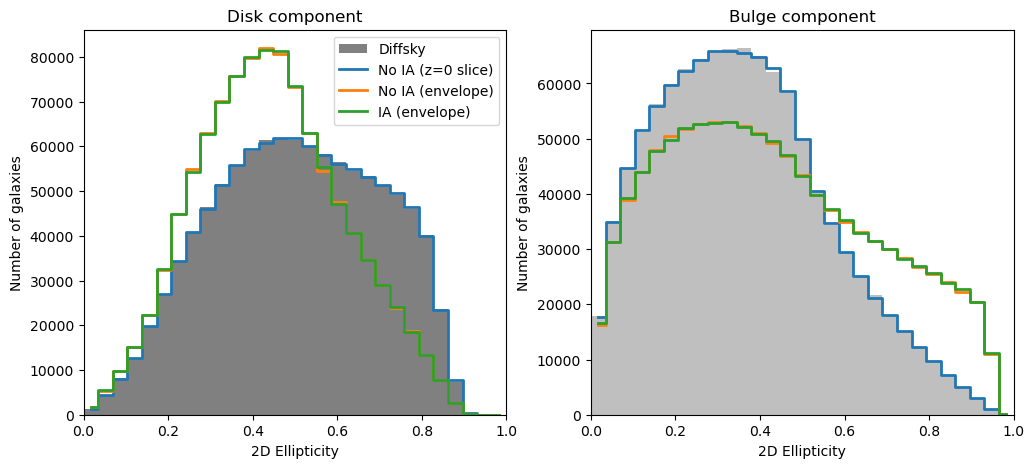

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(dataset.data["ellipticity_disk"].value, bins=ellip_bins, label='Diffsky', color='gray')
axes[0].plot(ellip_bin_center, ellip_disk_noIA_slice, label='No IA (z=0 slice)', drawstyle='steps-mid', lw=2)
axes[0].plot(ellip_bin_center, ellip_disk_noIA_envelope, label='No IA (envelope)',drawstyle='steps-mid', lw=2)
axes[0].plot(ellip_bin_center, ellip_disk_IA_envelope, label='IA (envelope)', drawstyle='steps-mid', lw=2)

axes[1].hist(dataset.data["ellipticity_bulge"].value, alpha=0.5, bins=ellip_bins, color='gray', label='Diffsky')
axes[1].plot(ellip_bin_center, ellip_bulge_noIA_slice, label='No IA (z=0 slice)', drawstyle='steps-mid', lw=2)
axes[1].plot(ellip_bin_center, ellip_bulge_noIA_envelope, label='No IA (envelope)', drawstyle='steps-mid', lw=2)
axes[1].plot(ellip_bin_center, ellip_bulge_IA_envelope, label='IA (envelope)', drawstyle='steps-mid', lw=2)

axes[0].legend()
axes[0].set(xlabel='2D Ellipticity', ylabel='Number of galaxies', title='Disk component', xlim=(0, 1))
axes[1].set(xlabel='2D Ellipticity', ylabel='Number of galaxies', title='Bulge component', xlim=(0, 1))

plt.show()

In [69]:
### Get the projected 2D halo shape 
halo_A_3D = np.array([dataset.data["top_host_infall_fof_halo_eigS3X"], 
                    dataset.data["top_host_infall_fof_halo_eigS3Y"], 
                    dataset.data["top_host_infall_fof_halo_eigS3Z"]]).T
halo_B_3D = np.array([dataset.data["top_host_infall_fof_halo_eigS2X"], 
                    dataset.data["top_host_infall_fof_halo_eigS2Y"], 
                    dataset.data["top_host_infall_fof_halo_eigS2Z"]]).T
halo_C_3D = np.array([dataset.data["top_host_infall_fof_halo_eigS1X"], 
                    dataset.data["top_host_infall_fof_halo_eigS1Y"], 
                    dataset.data["top_host_infall_fof_halo_eigS1Z"]]).T
# get the RA/Dec frame for the halo axes
ra_rad  = dataset.data['ra_obs'].to('rad').value
dec_rad = dataset.data['dec_obs'].to('rad').value
x_prime, y_prime, z_prime = observer_frame_axes(ra_rad, dec_rad)
halo_A_obs, halo_B_obs, halo_C_obs = transform_axes_to_frame(halo_A_3D, halo_B_3D, halo_C_3D,
                                                            x_prime, y_prime, z_prime)

alpha_halo, beta_halo, gamma_halo = euler_angles_ZXZ(halo_A_obs, halo_B_obs, halo_C_obs,
                                                     ellipsoid_domain=True)
E2D_halo_envelope = compute_ellipse2d(
            np.sqrt(np.sum(halo_A_obs * halo_A_obs, axis=-1)), 
            np.sqrt(np.sum(halo_B_obs * halo_B_obs, axis=-1)), 
            np.sqrt(np.sum(halo_C_obs * halo_C_obs, axis=-1)), 
             np.cos(beta_halo), alpha_halo - np.pi/2., gamma_halo, 
            envelop=True)
# get the comoving frame shapes
alphap_halo, betap_halo, gammap_halo = euler_angles_ZXZ(halo_A_3D, halo_B_3D, halo_C_3D,
                                                     ellipsoid_domain=True)
E2Dp_halo_envelope = compute_ellipse2d(
            np.sqrt(np.sum(halo_A_3D * halo_A_3D, axis=-1)), 
            np.sqrt(np.sum(halo_B_3D * halo_B_3D, axis=-1)), 
            np.sqrt(np.sum(halo_C_3D * halo_C_3D, axis=-1)), 
             np.cos(betap_halo), alphap_halo - np.pi/2., gammap_halo, 
            envelop=True)

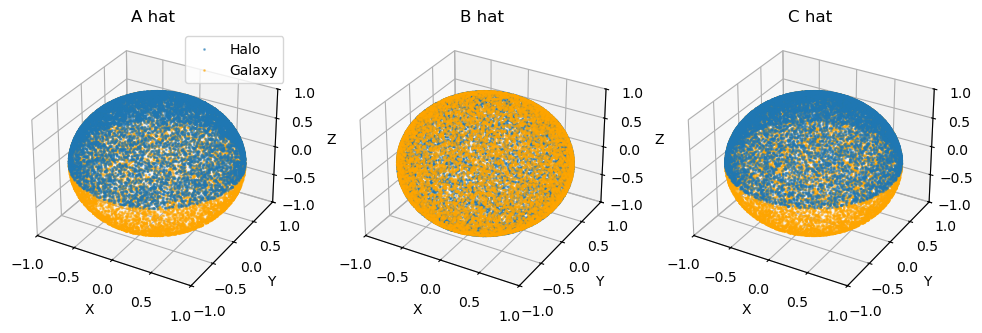

In [71]:
# show the 3D distribution of normalized halo A vectors
fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131, projection='3d')
#ax.view_init(elev=0, azim=70, roll=0)
halo_Ahat = halo_A_3D / np.linalg.norm(halo_A_3D, axis=-1, keepdims=True)
gal_A_3D = np.array([gal_axes_disk_IA_envelope["galaxy_axisA_x"], 
                    gal_axes_disk_IA_envelope["galaxy_axisA_y"], 
                    gal_axes_disk_IA_envelope["galaxy_axisA_z"]]).T
gal_Ahat = gal_A_3D / np.linalg.norm(gal_A_3D, axis=-1, keepdims=True)
ax1.scatter(halo_Ahat[::100, 0], halo_Ahat[::100, 1], halo_Ahat[::100, 2], s=1, alpha=0.5, label='Halo')
ax1.scatter(gal_Ahat[::100, 0], gal_Ahat[::100, 1], gal_Ahat[::100, 2], s=1, alpha=0.5, color='orange', label='Galaxy')
ax1.legend()
ax1.set_title("A hat")
ax1.set(xlabel='X', ylabel='Y', zlabel='Z')
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 1)
ax1.set_zlim(-1, 1)

ax2 = fig.add_subplot(132, projection='3d')
#ax.view_init(elev=0, azim=70, roll=0)
halo_Bhat = halo_B_3D / np.linalg.norm(halo_B_3D, axis=-1, keepdims=True)
gal_B_3D = np.array([gal_axes_disk_IA_envelope["galaxy_axisB_x"], 
                    gal_axes_disk_IA_envelope["galaxy_axisB_y"], 
                    gal_axes_disk_IA_envelope["galaxy_axisB_z"]]).T
gal_Bhat = gal_B_3D / np.linalg.norm(gal_B_3D, axis=-1, keepdims=True)
ax2.scatter(halo_Bhat[::100, 0], halo_Bhat[::100, 1], halo_Bhat[::100, 2], s=1, alpha=0.5, label='Halo')
ax2.scatter(gal_Bhat[::100, 0], gal_Bhat[::100, 1], gal_Bhat[::100, 2], s=1, alpha=0.5, color='orange', label='Galaxy')
ax2.set_title("B hat")
ax2.set(xlabel='X', ylabel='Y', zlabel='Z')
ax2.set_xlim(-1, 1)
ax2.set_ylim(-1, 1)
ax2.set_zlim(-1, 1)

ax3 = fig.add_subplot(133, projection='3d')
#ax.view_init(elev=0, azim=70, roll=0)
halo_Chat = halo_C_3D / np.linalg.norm(halo_C_3D, axis=-1, keepdims=True)
gal_C_3D = np.array([gal_axes_disk_IA_envelope["galaxy_axisC_x"], 
                    gal_axes_disk_IA_envelope["galaxy_axisC_y"], 
                    gal_axes_disk_IA_envelope["galaxy_axisC_z"]]).T
gal_Chat = gal_C_3D / np.linalg.norm(gal_C_3D, axis=-1, keepdims=True)
ax3.scatter(halo_Chat[::100, 0], halo_Chat[::100, 1], halo_Chat[::100, 2], s=1, alpha=0.5, label='Halo')
ax3.scatter(gal_Chat[::100, 0], gal_Chat[::100, 1], gal_Chat[::100, 2], s=1, alpha=0.5, color='orange', label='Galaxy')
ax3.set_title("C hat")
ax3.set(xlabel='X', ylabel='Y', zlabel='Z')
ax3.set_xlim(-1, 1)
ax3.set_ylim(-1, 1)
ax3.set_zlim(-1, 1)

plt.show()

Examine the misalignment angle distribution in 3D and 2D

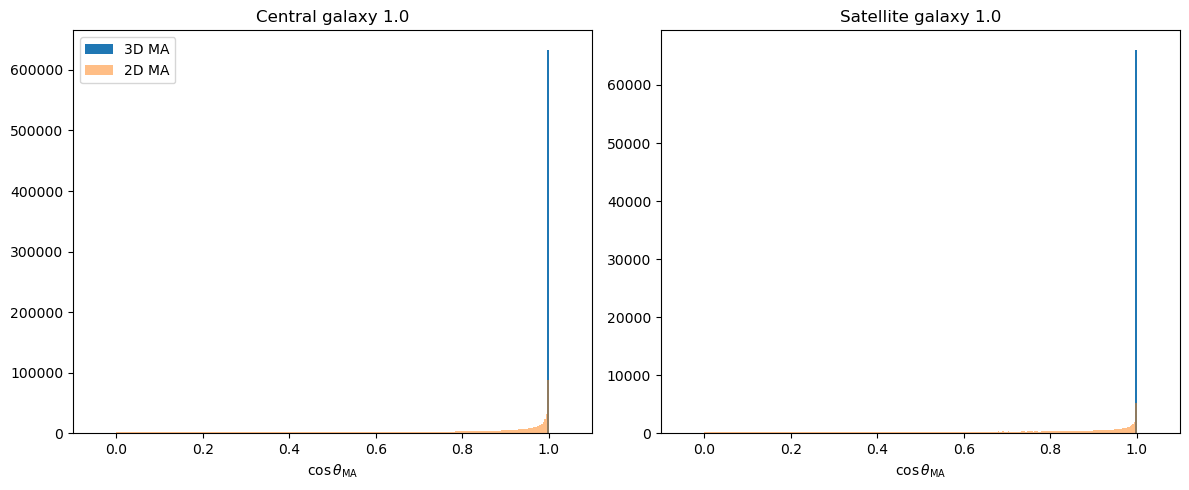

In [72]:
mu_bins = np.linspace(0, 1, 300)
### Take the central galaxies 
# 3D misalignment angle
central_A = np.array([gal_axes_disk_IA_envelope["galaxy_axisA_x"][central_mask], 
                        gal_axes_disk_IA_envelope["galaxy_axisA_y"][central_mask], 
                        gal_axes_disk_IA_envelope["galaxy_axisA_z"][central_mask]]).T
halo_A = np.array([dataset.data["top_host_infall_fof_halo_eigS3X"][central_mask], 
                    dataset.data["top_host_infall_fof_halo_eigS3Y"][central_mask], 
                    dataset.data["top_host_infall_fof_halo_eigS3Z"][central_mask]]).T
cos_angle_cen_3D = np.abs(np.sum(central_A * halo_A, axis=1) / (np.linalg.norm(central_A, axis=1) * np.linalg.norm(halo_A, axis=1)))
# 2D misalignment angle 
cos_angle_cen_2D = np.abs(np.cos(E2D_disk_IA_envelope.psi[central_mask] - E2D_halo_envelope.psi[central_mask]))


### Take the satellite galaxies
# 3D misalignment angle
satellite_A = np.array([gal_axes_disk_IA_envelope["galaxy_axisA_x"][satellite_mask], 
                        gal_axes_disk_IA_envelope["galaxy_axisA_y"][satellite_mask], 
                        gal_axes_disk_IA_envelope["galaxy_axisA_z"][satellite_mask]]).T
radial_vec = np.array([dataset.data["x_host"][satellite_mask] - dataset.data["x_nfw"][satellite_mask], 
                        dataset.data["y_host"][satellite_mask] - dataset.data["y_nfw"][satellite_mask], 
                        dataset.data["z_host"][satellite_mask] - dataset.data["z_nfw"][satellite_mask]]).T
cos_angle_sat_3D = np.abs(np.sum(satellite_A * radial_vec, axis=1) / (np.linalg.norm(satellite_A, axis=1) * np.linalg.norm(radial_vec, axis=1)))
# 2D misalignment angle
cos_angle_sat_2D = np.abs(np.cos(E2D_disk_IA_envelope.psi[satellite_mask] - E2D_halo_envelope.psi[satellite_mask]))

### Show the distribution of the cosine of the angle between the central galaxy major axis and the halo major axis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(cos_angle_cen_3D, bins=mu_bins, label='3D MA')
axes[0].hist(cos_angle_cen_2D, bins=mu_bins, label='2D MA', alpha=0.5)
axes[0].set(xlabel=r"$\cos \theta_\mathrm{MA}$", title="Central galaxy {}".format(central_alignment), xlim=(-0.1, 1.1))
axes[0].legend()
axes[1].hist(cos_angle_sat_3D, bins=mu_bins, label='3D MA')
axes[1].hist(cos_angle_sat_2D, bins=mu_bins, label='2D MA', alpha=0.5)
axes[1].set(xlabel=r"$\cos \theta_\mathrm{MA}$", title="Satellite galaxy {}".format(satellite_alignment), xlim=(-0.1, 1.1))
plt.tight_layout()
plt.show()

Now, we have the 2D shape of galaxies, and we can now try measure the 2PCF

In [ ]:
### Build galaxy shape and position catalogs
central_cat = treecorr.Catalog(
    ra=dataset.data[central_mask]['ra_obs'].to('rad').value, 
    dec=dataset.data[central_mask]['dec_obs'].to('rad').value, 
    r=dataset.cosmology.comoving_distance(dataset.data[central_mask]['redshift']).to("Mpc").value, 
    g1=(E2D_bulge_IA_envelope.ellipticity * np.cos(2*E2D_bulge_IA_envelope.psi))[central_mask], 
    g2=(E2D_bulge_IA_envelope.ellipticity * np.sin(2*E2D_bulge_IA_envelope.psi))[central_mask],
    ra_units='radians', dec_units='radians',)
N_central = np.sum(central_mask)

### Satellite galaxy: align radially towards the host halo center. 
# Note that RadialSatelliteAlignment has hard-coded column names, we use the module alignment model here
satellite_cat = treecorr.Catalog(
    ra=dataset.data[satellite_mask]['ra_obs'].to('rad').value, 
    dec=dataset.data[satellite_mask]['dec_obs'].to('rad').value, 
    r=dataset.cosmology.comoving_distance(dataset.data[satellite_mask]['redshift']).to("Mpc").value, 
    g1=(E2D_bulge_IA_envelope.ellipticity * np.cos(2*E2D_bulge_IA_envelope.psi))[satellite_mask], 
    g2=(E2D_bulge_IA_envelope.ellipticity * np.sin(2*E2D_bulge_IA_envelope.psi))[satellite_mask],
    ra_units='radians', dec_units='radians')
N_satellite = np.sum(satellite_mask)

### Random catalog for clustering measurement, shared by central and satellite galaxies
ra_rand, dec_rand, r_rand = make_random_catalog(
    dataset.data['ra_obs'].to('rad').value, 
    dataset.data['dec_obs'].to('rad').value, 
    dataset.cosmology.comoving_distance(dataset.data['redshift']).to("Mpc").value,
    n_randoms=1 * len(dataset),   # 10× is standard for Landy-Szalay
    n_ang_bins=20,                # finer = better hole detection, more rejection
    n_r_bins=15,
    unit='rad',
    seed=42,
)

rand_cat = treecorr.Catalog(
    ra=ra_rand, 
    dec=dec_rand, 
    r=r_rand, 
    ra_units='radians', dec_units='radians')
N_rand = len(ra_rand)

### Halo shape catalog as a reference for IA strength
halo_cat = treecorr.Catalog(
    ra=dataset.data['ra_obs'][central_mask].to('rad').value, 
    dec=dataset.data['dec_obs'][central_mask].to('rad').value, 
    r=dataset.cosmology.comoving_distance(dataset.data['redshift'][central_mask]).to("Mpc").value, 
    g1=(E2D_halo_envelope.ellipticity * np.cos(2*E2D_halo_envelope.psi))[central_mask], 
    g2=(E2D_halo_envelope.ellipticity * np.sin(2*E2D_halo_envelope.psi))[central_mask],
    ra_units='radians', dec_units='radians')


### Measure the 2PCF with TreeCorr Rperp metric
cfg = dict(
    min_sep   = 0.1,
    max_sep   = 120.0,
    nbins     = 20,
    bin_slop  = 0.0,          # IMPORTANT: exact rpar edges
    metric    = 'Rperp',    # rp = transverse separation
    min_rpar  = -100.0,
    max_rpar  = 100.0,
)


In [74]:
def measure_wgg(data_pos, rand_pos, cfg, file_name, num_threads=8, data_pos_2=None):
    dd = treecorr.NNCorrelation(**cfg)
    rr = treecorr.NNCorrelation(**cfg)
    dr = treecorr.NNCorrelation(**cfg)
    rd = treecorr.NNCorrelation(**cfg)

    if data_pos_2 is None:
        dd.process(data_pos, data_pos, num_threads=num_threads)
        rr.process(rand_pos, rand_pos, num_threads=num_threads)
        dr.process(data_pos, rand_pos, num_threads=num_threads)
        rd.process(rand_pos, data_pos, num_threads=num_threads)
    else:
        dd.process(data_pos, data_pos_2, num_threads=num_threads)
        rr.process(rand_pos, rand_pos, num_threads=num_threads)
        dr.process(data_pos, rand_pos, num_threads=num_threads)
        rd.process(rand_pos, data_pos_2, num_threads=num_threads)

    dd.write(file_name, rr=rr, dr=dr, rd=rd, file_type="ASCII", 
             write_patch_results=False, write_cov=False)

    return dd, rr, dr, rd

def measure_wgp(data_pos, rand_pos, data_shape, cfg, file_name, num_threads=8):
    dg = treecorr.NGCorrelation(**cfg)
    rg = treecorr.NGCorrelation(**cfg)

    dg.process(data_pos, data_shape, num_threads=num_threads)
    rg.process(rand_pos, data_shape, num_threads=num_threads)

    dg.write(file_name, rg=rg, file_type="ASCII", 
             write_patch_results=False, write_cov=False)
    
def measure_wpp(data_shape, cfg, file_name, num_threads=8, data_shape_2=None):
    pp = treecorr.GGCorrelation(**cfg)
    if data_shape_2 is None:
        pp.process(data_shape, num_threads=num_threads)
    else:
        pp.process(data_shape, data_shape_2, num_threads=num_threads)

    pp.write(file_name, file_type="ASCII", 
             write_patch_results=False, write_cov=False)

In [75]:
NUM_THREADS = 16

# print("Measuring wgg")
# print("\t\t\t---> central - central")
# t1 = time.time()
# measure_wgg(central_cat, rand_cat, cfg, "wgg_cen_cen.txt", num_threads=NUM_THREADS)
# t2 = time.time()
# print(f"Elapsed time: {t2 - t1:.2f} seconds for {N_central} central galaxies and {N_rand} random points")

# print("\t\t\t---> satellite - satellite")
# t1 = time.time()
# measure_wgg(satellite_cat, rand_cat, cfg, "wgg_sat_sat.txt", num_threads=NUM_THREADS)
# t2 = time.time()
# print(f"Elapsed time: {t2 - t1:.2f} second for {N_satellite} satellite galaxies and {N_rand} random points")

# print("\t\t\t---> central - satellite")
# t1 = time.time()
# measure_wgg(central_cat, rand_cat, cfg, "wgg_cen_sat.txt", data_pos_2=satellite_cat, num_threads=NUM_THREADS)
# t2 = time.time()
# print(f"Elapsed time: {t2 - t1:.2f} seconds for {N_central} central galaxies, {N_satellite} satellite galaxies and {N_rand} random points")

print("Measuring wg+")
print("\t\t\t---> central - central")
t1 = time.time()
measure_wgp(central_cat, rand_cat, central_cat, cfg, "wgp_cen_cen.txt", num_threads=NUM_THREADS)
t2 = time.time()
print(f"Elapsed time: {t2 - t1:.2f} seconds for {N_central} central galaxies and {N_rand} random points")
print("\t\t\t---> satellite - satellite")
t1 = time.time()
measure_wgp(satellite_cat, rand_cat, satellite_cat, cfg, "wgp_sat_sat.txt", num_threads=NUM_THREADS)
t2 = time.time()
print(f"Elapsed time: {t2 - t1:.2f} seconds for {N_satellite} satellite galaxies and {N_rand} random points")
print("\t\t\t---> central - satellite")
t1 = time.time()
measure_wgp(central_cat, rand_cat, satellite_cat, cfg, "wgp_cen_sat.txt", num_threads=NUM_THREADS)
t2 = time.time()
print(f"Elapsed time: {t2 - t1:.2f} seconds for {N_central} central galaxies, {N_satellite} satellite galaxies and {N_rand} random points")
print("\t\t\t---> satellite - central")
t1 = time.time()
measure_wgp(satellite_cat, rand_cat, central_cat, cfg, "wgp_sat_cen.txt", num_threads=NUM_THREADS)
t2 = time.time()
print(f"Elapsed time: {t2 - t1:.2f} seconds for {N_satellite} satellite galaxies, {N_central} central galaxies and {N_rand} random points")
print("\t\t\t---> halo - halo")
t1 = time.time()
measure_wgp(halo_cat, rand_cat, halo_cat, cfg, "wgp_halo_halo.txt", num_threads=NUM_THREADS)
t2 = time.time()
print(f"Elapsed time: {t2 - t1:.2f} seconds for {N_central} halos and {N_rand} random points")

print("Measuring w++")
print("\t\t\t---> central - central")
t1 = time.time()
measure_wpp(central_cat, cfg, "wpp_cen_cen.txt", num_threads=NUM_THREADS)
t2 = time.time()
print(f"Elapsed time: {t2 - t1:.2f} seconds for {N_central} central galaxies")

print("\t\t\t---> satellite - satellite")
t1 = time.time()
measure_wpp(satellite_cat, cfg, "wpp_sat_sat.txt", num_threads=NUM_THREADS)
t2 = time.time()
print(f"Elapsed time: {t2 - t1:.2f} seconds for {N_satellite} satellite galaxies")

print("\t\t\t---> central - satellite")
t1 = time.time()
measure_wpp(central_cat, cfg, "wpp_cen_sat.txt", data_shape_2=satellite_cat, num_threads=NUM_THREADS)
t2 = time.time()
print(f"Elapsed time: {t2 - t1:.2f} seconds for {N_central} central galaxies and {N_satellite} satellite galaxies")

print("\t\t\t---> halo - halo")
t1 = time.time()
measure_wpp(halo_cat, cfg, "wpp_halo_halo.txt", num_threads=NUM_THREADS)
t2 = time.time()
print(f"Elapsed time: {t2 - t1:.2f} seconds for {N_central} halos")

Measuring wg+
			---> central - central
Elapsed time: 19.17 seconds for 946703 central galaxies and 1047021 random points
			---> satellite - satellite
Elapsed time: 1.41 seconds for 100318 satellite galaxies and 1047021 random points
			---> central - satellite
Elapsed time: 2.53 seconds for 946703 central galaxies, 100318 satellite galaxies and 1047021 random points
			---> satellite - central
Elapsed time: 8.27 seconds for 100318 satellite galaxies, 946703 central galaxies and 1047021 random points
			---> halo - halo
Elapsed time: 19.84 seconds for 946703 halos and 1047021 random points
Measuring w++
			---> central - central
Elapsed time: 7.36 seconds for 946703 central galaxies
			---> satellite - satellite
Elapsed time: 0.23 seconds for 100318 satellite galaxies
			---> central - satellite
Elapsed time: 1.72 seconds for 946703 central galaxies and 100318 satellite galaxies
			---> halo - halo
Elapsed time: 7.20 seconds for 946703 halos


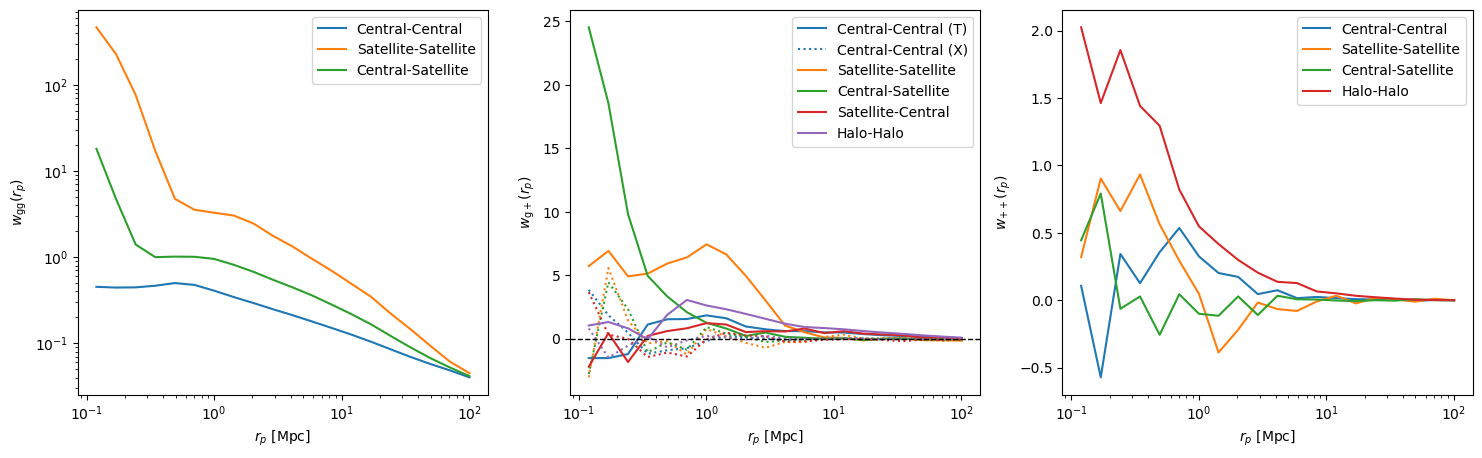

In [81]:
# get default color cycle
prop_cycle = plt.rcParams['axes.prop_cycle']

wgg_cen_cen = np.genfromtxt("wgg_cen_cen.txt", names=True, skip_header=1)
wgg_sat_sat = np.genfromtxt("wgg_sat_sat.txt", names=True, skip_header=1)
wgg_cen_sat = np.genfromtxt("wgg_cen_sat.txt", names=True, skip_header=1)

wgp_cen_cen = np.genfromtxt("wgp_cen_cen.txt", names=True, skip_header=1)
wgp_sat_sat = np.genfromtxt("wgp_sat_sat.txt", names=True, skip_header=1)
wgp_cen_sat = np.genfromtxt("wgp_cen_sat.txt", names=True, skip_header=1)
wgp_sat_cen = np.genfromtxt("wgp_sat_cen.txt", names=True, skip_header=1)
wgp_halo_halo = np.genfromtxt("wgp_halo_halo.txt", names=True, skip_header=1)

wpp_cen_cen = np.genfromtxt("wpp_cen_cen.txt", names=True, skip_header=1)
wpp_sat_sat = np.genfromtxt("wpp_sat_sat.txt", names=True, skip_header=1)
wpp_cen_sat = np.genfromtxt("wpp_cen_sat.txt", names=True, skip_header=1)
wpp_halo_halo = np.genfromtxt("wpp_halo_halo.txt", names=True, skip_header=1)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(wgg_cen_cen["r_nom"], wgg_cen_cen["xi"], label='Central-Central')
axes[0].plot(wgg_sat_sat["r_nom"], wgg_sat_sat["xi"], label='Satellite-Satellite')
axes[0].plot(wgg_cen_sat["r_nom"], wgg_cen_sat["xi"], label='Central-Satellite')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set(xlabel=r'$r_p$ [Mpc]', ylabel=r'$w_\mathrm{gg}(r_p)$')
axes[0].legend()

# Note that w_g+ and gamma_T have different sign conventions.
two_Pi_max = (cfg['max_rpar']-cfg['min_rpar'])
axes[1].plot(wgp_cen_cen["r_nom"], -1*wgp_cen_cen["gamT"]*two_Pi_max, label='Central-Central (T)', 
             color=prop_cycle.by_key()['color'][0])
axes[1].plot(wgp_cen_cen["r_nom"], -1*wgp_cen_cen["gamX"]*two_Pi_max, label='Central-Central (X)', ls=':',
             color=prop_cycle.by_key()['color'][0])
axes[1].plot(wgp_sat_sat["r_nom"], -1*wgp_sat_sat["gamT"]*two_Pi_max, label='Satellite-Satellite',
             color=prop_cycle.by_key()['color'][1])
axes[1].plot(wgp_sat_sat["r_nom"], -1*wgp_sat_sat["gamX"]*two_Pi_max, ls=':',
             color=prop_cycle.by_key()['color'][1])
axes[1].plot(wgp_cen_sat["r_nom"], -1*wgp_cen_sat["gamT"]*two_Pi_max, label='Central-Satellite',
             color=prop_cycle.by_key()['color'][2])
axes[1].plot(wgp_cen_sat["r_nom"], -1*wgp_cen_sat["gamX"]*two_Pi_max, ls=':',
             color=prop_cycle.by_key()['color'][2])
axes[1].plot(wgp_sat_cen["r_nom"], -1*wgp_sat_cen["gamT"]*two_Pi_max, label='Satellite-Central',
             color=prop_cycle.by_key()['color'][3])
axes[1].plot(wgp_sat_cen["r_nom"], -1*wgp_sat_cen["gamX"]*two_Pi_max, ls=':',
             color=prop_cycle.by_key()['color'][3])
axes[1].plot(wgp_halo_halo["r_nom"], -1*wgp_halo_halo["gamT"]*two_Pi_max, label='Halo-Halo',
             color=prop_cycle.by_key()['color'][4])
axes[1].plot(wgp_halo_halo["r_nom"], -1*wgp_halo_halo["gamX"]*two_Pi_max, ls=':',
             color=prop_cycle.by_key()['color'][4])
axes[1].set_xscale('log')
axes[1].set_yscale('linear')
axes[1].set(xlabel=r'$r_p$ [Mpc]', ylabel=r'$w_\mathrm{g+}(r_p)$')
axes[1].legend()
axes[1].axhline(0, color='k', ls='--', lw=1)

axes[2].plot(wpp_cen_cen["r_nom"], wpp_cen_cen["xip"]*two_Pi_max, label='Central-Central',
             color=prop_cycle.by_key()['color'][0])
#axes[2].plot(wpp_cen_cen["r_nom"], wpp_cen_cen["xim"]*two_Pi_max, label='Central-Central (XX)', ls=':',
#             color=prop_cycle.by_key()['color'][0])
axes[2].plot(wpp_sat_sat["r_nom"], wpp_sat_sat["xip"]*two_Pi_max, label='Satellite-Satellite',
             color=prop_cycle.by_key()['color'][1])
#axes[2].plot(wpp_sat_sat["r_nom"], wpp_sat_sat["xim"]*two_Pi_max, ls=':',
#             color=prop_cycle.by_key()['color'][1])
axes[2].plot(wpp_cen_sat["r_nom"], wpp_cen_sat["xip"]*two_Pi_max, label='Central-Satellite',
             color=prop_cycle.by_key()['color'][2])
#axes[2].plot(wpp_cen_sat["r_nom"], wpp_cen_sat["xim"]*two_Pi_max, ls=':',
#             color=prop_cycle.by_key()['color'][2])
axes[2].plot(wpp_halo_halo["r_nom"], wpp_halo_halo["xip"]*two_Pi_max, label='Halo-Halo',
             color=prop_cycle.by_key()['color'][3])
#axes[2].plot(wpp_halo_halo["r_nom"], wpp_halo_halo["xim"]*two_Pi_max, ls=':',
#             color=prop_cycle.by_key()['color'][3])

axes[2].set_xscale('log')
axes[2].set_yscale('linear')
axes[2].set(xlabel=r'$r_p$ [Mpc]', ylabel=r'$w_\mathrm{++}(r_p)$')
axes[2].legend()
plt.show()